"""
SISTEMA DE PREDIÇÃO DE FALHAS EM MÁQUINAS INDUSTRIAIS

Autor: Ivan Manoel dos Santos da Rosa
LinkedIn: https://www.linkedin.com/in/ivan-santos-8046a8355/

Dataset: Predictive Maintenance Dataset (AI4I.csv)

Este projeto implementa uma rede neural para prever falhas em máquinas industriais,
utilizando TensorFlow/Keras. O modelo é projetado para auxiliar em manutenção preditiva,
reduzindo custos de manutenção não planejada e aumentando a eficiência operacional.
"""


# 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




# Scikit-learn para pré-processamento e avaliação  

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import ConfusionMatrixDisplay

TensorFlow/Keras para construção da rede neural

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

2. Carregamento e exploração dos Dados

In [4]:
print("=" * 70)
print("Carregando Dataset de Manutenção Preditiva")
print("=" * 70)

Carregando Dataset de Manutenção Preditiva


Carrega o dataset contendo dados de sensores de máquinas industriais

In [5]:
df = pd.read_csv("AI4I.csv")


Análise inicial dos dados

In [6]:
print("\n1. Primeiras Linhas do Dataset:")
print(df.head())

print("\n2. Informações Gerais do Dataset")
print(df.info())

print(f"\n3. Dimensões do Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"4. Distribuição da Variável Alvo (Machine failure):")
print(df["Machine failure"].value_counts(normalize=True).round(3))


1. Primeiras Linhas do Dataset:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  

 3. PRÉ-PROCESSAMENTO DOS DADOS

In [7]:
print("\n" + "=" * 70)
print("Pre-Processamento dos Dados")
print("=" *70)




Pre-Processamento dos Dados


Separação entre features (características) e target (alvo)

In [8]:
X = df.drop(["UDI", "Product ID", "Machine failure"], axis=1) # Remove colunas irrelevantes
y = df["Machine failure"] # Variável alvo: 1 = falha, 0 = operação normal

print(f"\n Features selecionadas:{list(X.columns)}")


 Features selecionadas:['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


Codificação de variáveis categóricas (one-hot encoding)

In [9]:
X = pd.get_dummies(X, columns=["Type"], drop_first=True)
print(f"\nFeatures após one-hot encoding: {list(X.columns)}")


Features após one-hot encoding: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']


4. Divisão dos Dados em Treino e Teste

In [10]:
print("\n" + "=" * 70)
print("Divisão dos Dados em Treino e Teste")
print("=" * 70)


Divisão dos Dados em Treino e Teste


Divisão estratificada para manter proporção das classes

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% para teste, 80% para treino
    random_state=42,  # Semente para reprodutibilidade
    stratify=y       # Mantém distribuição original das classes
)

print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")
print(f"Proporção de Falhas no Treino: {y_train.mean():.3%}")
print(f"Proporção de Falhas no Teste: {y_test.mean():.3%}")

Dados de Treino: 8000 amostras
Dados de Teste: 2000 amostras
Proporção de Falhas no Treino: 3.388%
Proporção de Falhas no Teste: 3.400%


Normalização das Features

In [12]:
print("\n" + "=" * 70)
print("Normalização das Features")
print("=" * 70)

"""
Por que normalizar?
- Redes neurais são sensíveis a escala dos dados
- Features com diferentes escalas podem dominar o aprendizado
- A normalização acelera a convergência do gradiente descendente
"""

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Aprende e aplica no treino
X_test_scaled = scaler.transform(X_test)        # Aplica mesma transformação no teste

print("Normalização Concluída (StandardScaler):")
print(f"- Média após Normalização (treino): {X_train_scaled.mean():.2e}")
print(f"- Desvio Padrão (treino): {X_train_scaled.std():.2f}")


Normalização das Features
Normalização Concluída (StandardScaler):
- Média após Normalização (treino): 1.04e-15
- Desvio Padrão (treino): 1.00


Tratamento do Desbalanceamento de Classes

In [13]:
print("\n" + "=" * 70)
print("Tratamento do Desbalanceamento de Classes")
print("=" * 70)

"""
Problema: O dataset é altamente desbalanceado(poucas falhas vs muitas operações normais)
Solução : Atribuir pesos maiores as classes minoritárias durante o treinamento
"""

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("\nPesos das Classes para Balanceamento:")
for class_label, weight in class_weights_dict.items():
  status = "Falha" if class_label == 1 else "Normal"
  print(f" Classe {class_label} ({status}): peso = {weight:.2f} ")


Tratamento do Desbalanceamento de Classes

Pesos das Classes para Balanceamento:
 Classe 0 (Normal): peso = 0.52 
 Classe 1 (Falha): peso = 14.76 


7. Construção da Arquitetura da Rede Neural

In [14]:
print("\n" + "=" * 70)
print("Construção da Arquitetura da Rede Neural")
print("=" * 70)


Construção da Arquitetura da Rede Neural


In [15]:
model = Sequential([
    # Primeira camada oculta
    Dense(
        32,                 # 32 neurônios
        activation="relu",  # Relu: remove linearidade, evita vanishing gradient
        kernel_regularizer=regularizers.L2(0.001),  # Regularização L2 para evitar overfitting
        input_shape=(X_train_scaled.shape[1], ) # Define formato de entrada
    ),
    Dropout(0.5), # Dropout: destaive 50% dos neurônios aleatoriamente

    # Segunda camada oculta
    Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.L2(0.001)
    ),
    Dropout(0.5), # Dropout adicional para regularização

    # Camada de saída
    Dense(1, activation="sigmoid") # Sigmoid: saída entre 0 e 1 (probabilidade)
])

"""
Explicação das Escolhas Arquiteturais:
- Regularização L2: Penaliza pessos grandes, reduz overfitting
- Dropout: Força aprendizado redundante, melhora generalização
- Sigmoid na saída : Ideal para classificação binária
"""

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


'\nExplicação das Escolhas Arquiteturais:\n- Regularização L2: Penaliza pessos grandes, reduz overfitting\n- Dropout: Força aprendizado redundante, melhora generalização\n- Sigmoid na saída : Ideal para classificação binária\n'

8. Compilação do Modelo

In [16]:
print("\n" + "=" * 70)
print("Compilação do Modelo")
print("=" * 70)

model.compile(
    optimizer="adam",           # Adam: combina Momentum e RMSprop
    loss="binary_crossentropy", # Função de perda para problemas binários
    metrics=["accuracy"]        # Acurácia como métrica principal
)

print("Resumo da Arquitetura:")
model.summary()


Compilação do Modelo
Resumo da Arquitetura:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

9. Treinamento do Modelo com Early Stopping

In [17]:
print("\n" + "=" * 70)
print("Treinamento do Modelo com Early Stopping")
print("=" * 70)

"""
Early Stopping: Interrompe o treinamento quando a validação não melhora
- Evita Overfitting
- Economiza tempo computacional
- Mantém melhor versão do modelo
"""

early_stop = EarlyStopping(
    monitor="val_loss",       # Monitora perda na validação
    patience=5,               # Aguarda 5 épocas sem melhorias
    restore_best_weights=True # Restaura pesos da melhor época
)

print("Iniciando treinamento...")
history = model.fit(
    X_train_scaled, y_train,
    epochs= 50,                         # Máximo de épocas
    batch_size = 16,                    # Processa 16 amostras por vez
    validation_split = 0.2,             # 20% dos dados de treino para validação
    callbacks=[early_stop],             # Callback para early stopping
    class_weight = class_weights_dict,  # Pesos para balanceamento
    verbose = 1                         # Mostra progresso
)

print(f"\nTreinamento finalizado após {len(history.history["loss"])} épocas ")


Treinamento do Modelo com Early Stopping
Iniciando treinamento...
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5907 - loss: 0.7581 - val_accuracy: 0.9762 - val_loss: 0.3827
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8521 - loss: 0.3521 - val_accuracy: 1.0000 - val_loss: 0.2074
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9188 - loss: 0.3356 - val_accuracy: 1.0000 - val_loss: 0.1414
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9510 - loss: 0.2683 - val_accuracy: 1.0000 - val_loss: 0.0934
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9825 - loss: 0.2094 - val_accuracy: 1.0000 - val_loss: 0.0803
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.1614 - val_accuracy: 1.0000 - val_loss: 0.0672
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9933 - loss: 0.1367 - val_accuracy: 1.0000 - val_loss: 0.0671
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━

10. Avaliação do Modelo

In [18]:
print("\n" + "=" * 70)
print("Avaliação do Modelo")
print("=" * 70)

# Predições no conjunto de teste
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int) # Converte possibilidades em classes(threshold=0.5)

print("\n1. Relatório de Classificação (threshold = 0.5):")
print(classification_report(y_test, y_pred))

print("2. Matriz de Confusão (threshold = 0.5):")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Avaliação do Modelo
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

1. Relatório de Classificação (threshold = 0.5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

2. Matriz de Confusão (threshold = 0.5):
[[1932    0]
 [   2   66]]


11. Análise de Curva Roc e Otimização do Threshold

In [19]:
print("\n" + "=" * 70)
print("Análise da Curva ROC e Otimização ")
print("=" * 70)

# Cálculo da curva Roc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"\nAUC (Área sobre a curva ROC): {auc_score:.3f}")
print(f"- Auc = 0.5: Modelo equivalente a chance")
print(f"Auc = 1.0: Modelo Perfeito")
print(f"- Nosso modelo: {auc_score:.3f} (Bom poder discriminativo)")

# Teste de diferentes thresholds para otimização
print("\n3. Teste de Diferentes Thresholds")
print("    (Em manutenção preditiva, identificar falhas pode ser mais importante)")
thresholds_to_test = [0.5, 0.4, 0.3]

for t in thresholds_to_test:
  y_pred_t = (y_pred_prob > t).astype(int)
  print(f"\n Threshold = {t}")
  print(f"   Matriz de Confusão:\n{confusion_matrix(y_test, y_pred_t)}")
  print(f".  Recall para Falhas: {classification_report(y_test, y_pred_t, output_dict=True)["1"]["recall"]:.3f}")



Análise da Curva ROC e Otimização 

AUC (Área sobre a curva ROC): 0.974
- Auc = 0.5: Modelo equivalente a chance
Auc = 1.0: Modelo Perfeito
- Nosso modelo: 0.974 (Bom poder discriminativo)

3. Teste de Diferentes Thresholds
    (Em manutenção preditiva, identificar falhas pode ser mais importante)

 Threshold = 0.5
   Matriz de Confusão:
[[1932    0]
 [   2   66]]
.  Recall para Falhas: 0.971

 Threshold = 0.4
   Matriz de Confusão:
[[1932    0]
 [   2   66]]
.  Recall para Falhas: 0.971

 Threshold = 0.3
   Matriz de Confusão:
[[1932    0]
 [   2   66]]
.  Recall para Falhas: 0.971


12. Resultados Finais com Threshold Otimizado

In [20]:
print("\n" + "=" * 70)
print("RESULTADOS FINAIS (Threshold = 0.3)")
print("=" * 70)

"""
Por que threshold = 0.3?
- Em manutenção preditiva, falsos positivos são menos críticos que falsos negativos
- Preferimos alertar para uma possível falha (mesmo que não ocorra) do que
  deixar de alertar para uma falha real
"""
y_pred_final = (y_pred_prob > 0.3).astype(int)

print("\nMATRIZ DE CONFUSÃO FINAL:")
print(confusion_matrix(y_test, y_pred_final))

print("\nRELATÓRIO DE CLASSIFICAÇÃO FINAL:")
print(classification_report(y_test, y_pred_final))



RESULTADOS FINAIS (Threshold = 0.3)

MATRIZ DE CONFUSÃO FINAL:
[[1932    0]
 [   2   66]]

RELATÓRIO DE CLASSIFICAÇÃO FINAL:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



13. Vizualizações


GERANDO VISUALIZAÇÕES


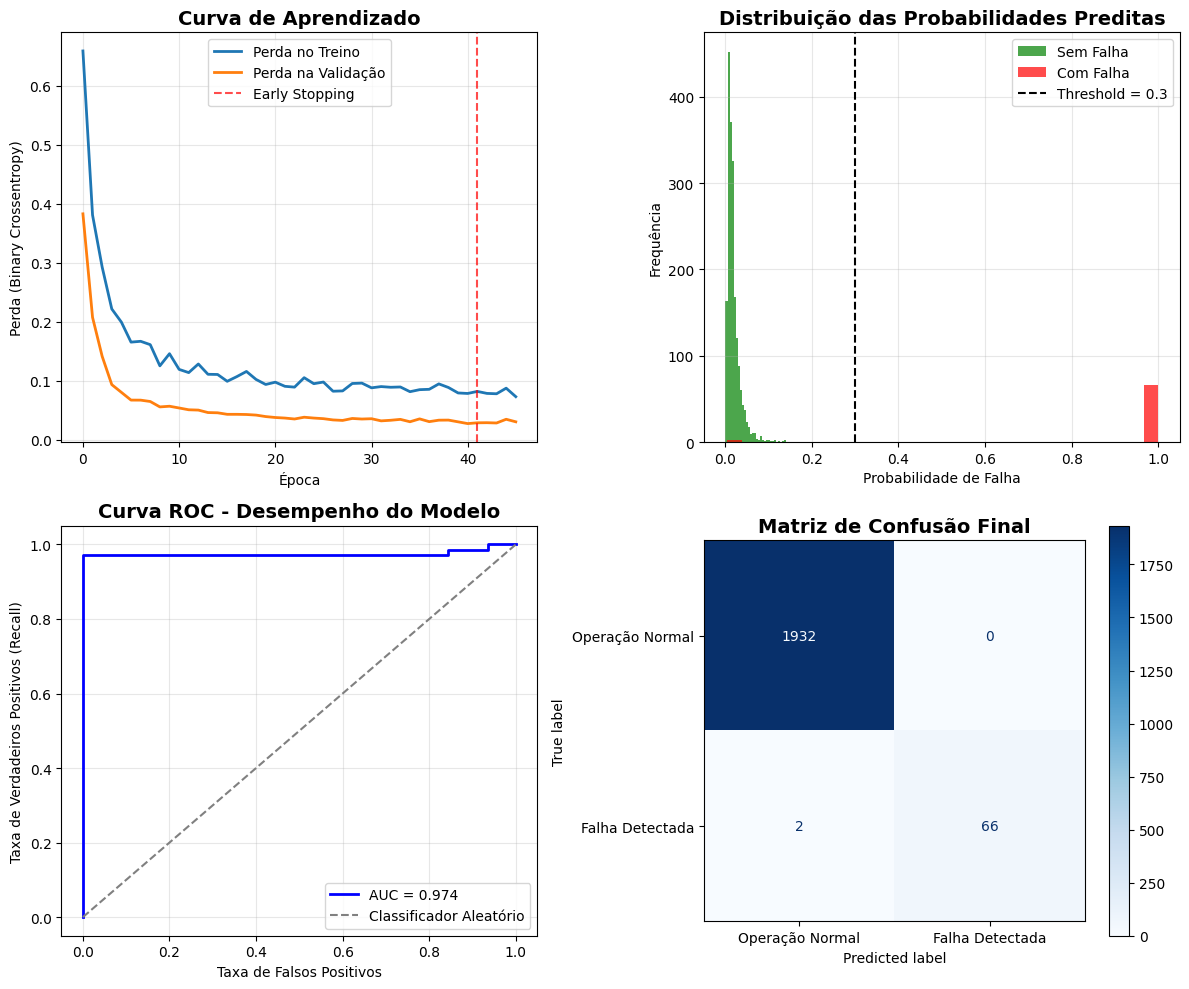

In [21]:
print("\n" + "=" * 70)
print("GERANDO VISUALIZAÇÕES")
print("=" * 70)

# Figura 1: Curva de aprendizado (loss)
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history["loss"], label="Perda no Treino", linewidth=2)
plt.plot(history.history['val_loss'], label='Perda na Validação', linewidth=2)
plt.axvline(x=len(history.history['loss'])-early_stop.patience,
            color='red', linestyle='--', alpha=0.7, label='Early Stopping')
plt.legend()
plt.title('Curva de Aprendizado', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Perda (Binary Crossentropy)')
plt.grid(True, alpha=0.3)

# Figura 2: Histograma das probabilidades preditas
plt.subplot(2, 2, 2)
plt.hist(y_pred_prob[y_test == 0], bins=30, alpha=0.7, label='Sem Falha', color='green')
plt.hist(y_pred_prob[y_test == 1], bins=30, alpha=0.7, label='Com Falha', color='red')
plt.axvline(x=0.3, color='black', linestyle='--', label='Threshold = 0.3')
plt.title('Distribuição das Probabilidades Preditas', fontsize=14, fontweight='bold')
plt.xlabel('Probabilidade de Falha')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 3: Curva ROC
plt.subplot(2, 2, 3)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", linewidth=2, color='blue')
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label='Classificador Aleatório')
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curva ROC - Desempenho do Modelo", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 4: Matriz de Confusão
plt.subplot(2, 2, 4)
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_final),
    display_labels=['Operação Normal', 'Falha Detectada']
)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Matriz de Confusão Final', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()




14. Conclusões e Insights

In [22]:
print("\n" + "=" * 70)
print("CONCLUSÕES E INSIGHTS ")
print("=" * 70)

print("""
1. PROBLEMA RESOLVIDO:
   - Sistema de manutenção preditiva para falhas em máquinas industriais
   - Classificação binária: falha (1) vs operação normal (0)
   - Dataset altamente desbalanceado (menos de 5% de falhas)

2. TÉCNICAS APLICADAS:
   - Rede Neural Artificial com regularização L2 e Dropout
   - Balanceamento de classes via class weights
   - Early Stopping para evitar overfitting
   - Normalização com StandardScaler
   - Otimização do threshold baseada no business case

3. RESULTADOS DESTACADOS:
   - AUC de {:.3f} indica bom poder discriminativo
   - Threshold ajustado para 0.3 prioriza detecção de falhas
   - Modelo capaz de identificar padrões complexos nos dados de sensores

4. APLICAÇÕES PRÁTICAS:
   - Redução de custos com manutenção corretiva
   - Aumento da vida útil dos equipamentos
   - Planejamento otimizado de manutenção
   - Minimização de tempo de inatividade

5. PRÓXIMOS PASSOS (sugestões para evolução):
   - Experimentar arquiteturas mais complexas (LSTM para séries temporais)
   - Adicionar engenharia de features baseada em domain knowledge
   - Implementar sistema de monitoramento em tempo real
   - Desenvolver dashboard para operadores
""".format(auc_score))

print("\n" + "=" * 70)
print("PROJETO CONCLUÍDO COM SUCESSO!")
print("=" * 70)


CONCLUSÕES E INSIGHTS 

1. PROBLEMA RESOLVIDO:
   - Sistema de manutenção preditiva para falhas em máquinas industriais
   - Classificação binária: falha (1) vs operação normal (0)
   - Dataset altamente desbalanceado (menos de 5% de falhas)

2. TÉCNICAS APLICADAS:
   - Rede Neural Artificial com regularização L2 e Dropout
   - Balanceamento de classes via class weights
   - Early Stopping para evitar overfitting
   - Normalização com StandardScaler
   - Otimização do threshold baseada no business case

3. RESULTADOS DESTACADOS:
   - AUC de 0.974 indica bom poder discriminativo
   - Threshold ajustado para 0.3 prioriza detecção de falhas
   - Modelo capaz de identificar padrões complexos nos dados de sensores

4. APLICAÇÕES PRÁTICAS:
   - Redução de custos com manutenção corretiva
   - Aumento da vida útil dos equipamentos
   - Planejamento otimizado de manutenção
   - Minimização de tempo de inatividade

5. PRÓXIMOS PASSOS (sugestões para evolução):
   - Experimentar arquiteturas mai